## `RainFall Prediction Analysis`

### `Importing Libraries`

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay


from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

### `Importing and Reading Dataset`

In [114]:
rainfall = pd.read_csv('../Dataset/Rainfall.csv')

rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


### `Summary Statistics`

In [115]:
rainfall.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [116]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


### `Handling Missing Values`

In [117]:
rainfall.isnull().sum().sort_values(ascending=False)

windspeed                 1
         winddirection    1
day                       0
pressure                  0
temparature               0
maxtemp                   0
mintemp                   0
dewpoint                  0
cloud                     0
humidity                  0
sunshine                  0
rainfall                  0
dtype: int64

### `Using Simple Imputer` to Handle Missing Value

In [118]:
imputer = SimpleImputer(strategy='median')

missing_col = rainfall.select_dtypes(include=[np.number])

for cols in missing_col:
    rainfall[cols] = imputer.fit_transform(rainfall[[cols]])

In [119]:
rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1.0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,yes,9.3,80.0,26.3
1,2.0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,yes,0.6,50.0,15.3
2,3.0,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,yes,0.0,40.0,14.2
3,4.0,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,yes,1.0,50.0,16.9
4,5.0,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,yes,0.0,40.0,13.7


### `Handling Outliers`

In [120]:
q1 = rainfall.select_dtypes(include=[np.number]).quantile(0.25)
q2 = rainfall.select_dtypes(include=[np.number]).quantile(0.75)

IQR = q2 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q2 + 1.5 * IQR

print('Lower Bound \n', lower_bound)
print('Upper Bound \n', upper_bound)

Lower Bound 
 day                       -14.5000
pressure                  994.1000
maxtemp                     6.2000
temparature                 4.1625
mintemp                     2.9500
dewpoint                    2.8125
humidity                   57.0000
cloud                      13.0000
sunshine                  -11.0500
         winddirection   -185.0000
windspeed                  -7.4250
dtype: float64
Upper Bound 
 day                         45.5000
pressure                  1032.5000
maxtemp                     46.2000
temparature                 43.2625
mintemp                     40.7500
dewpoint                    38.3125
humidity                   105.0000
cloud                      133.0000
sunshine                    19.7500
         winddirection     415.0000
windspeed                   48.9750
dtype: float64


In [121]:
for cols in rainfall.select_dtypes(include=[np.number]):
    mask = (rainfall[cols] < lower_bound[cols]) | (rainfall[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols} : {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].min():.2f}')

pressure  : 2 outliers | bounds=[994.10, 1032.50] | actual_min=994.10, actual_max=1032.50
dewpoint : 5 outliers | bounds=[2.81, 38.31] | actual_min=2.81, actual_max=38.31
humidity  : 10 outliers | bounds=[57.00, 105.00] | actual_min=57.00, actual_max=105.00
cloud  : 4 outliers | bounds=[13.00, 133.00] | actual_min=13.00, actual_max=133.00
windspeed : 5 outliers | bounds=[-7.42, 48.97] | actual_min=-7.42, actual_max=48.97


### `Visualizing the Outliers`

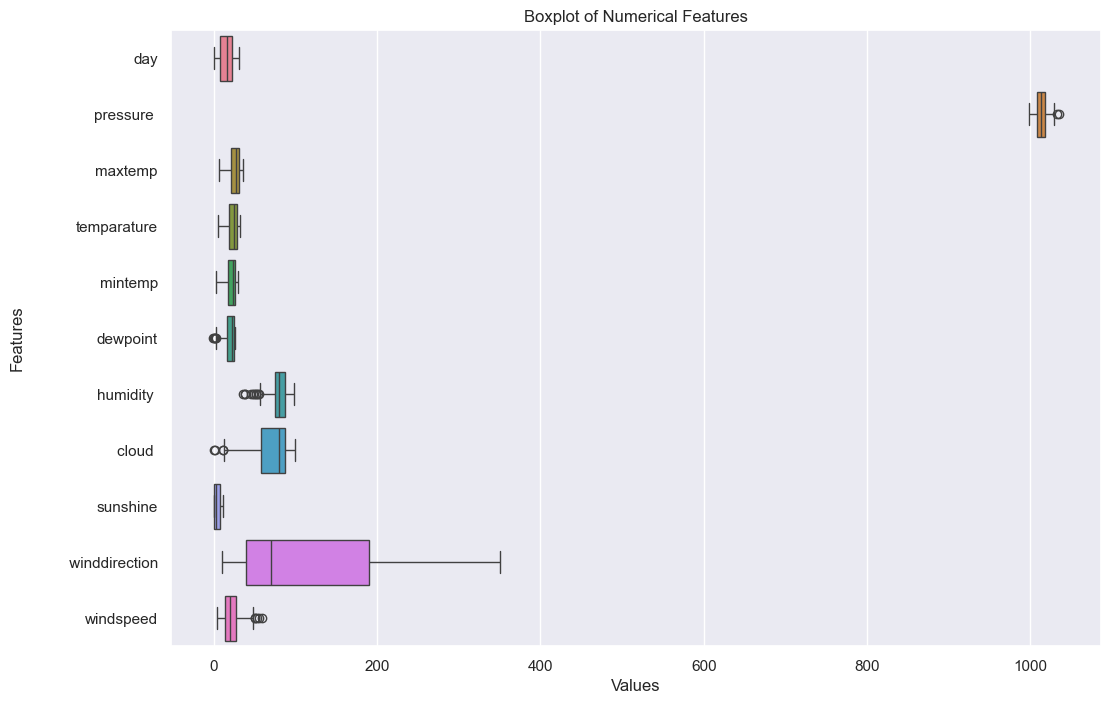

In [122]:
plt.figure(figsize=(12, 8))

sns.boxplot(rainfall.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

### `Winsorization` Replacing outlier with boundary values

In [123]:
for col in rainfall.select_dtypes(include=[np.number]):
    q1 = rainfall[col].quantile(0.25)
    q3 = rainfall[col].quantile(0.75)
    IQR = q3 -q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    rainfall[col] = rainfall[col].clip(lower_bound, upper_bound)

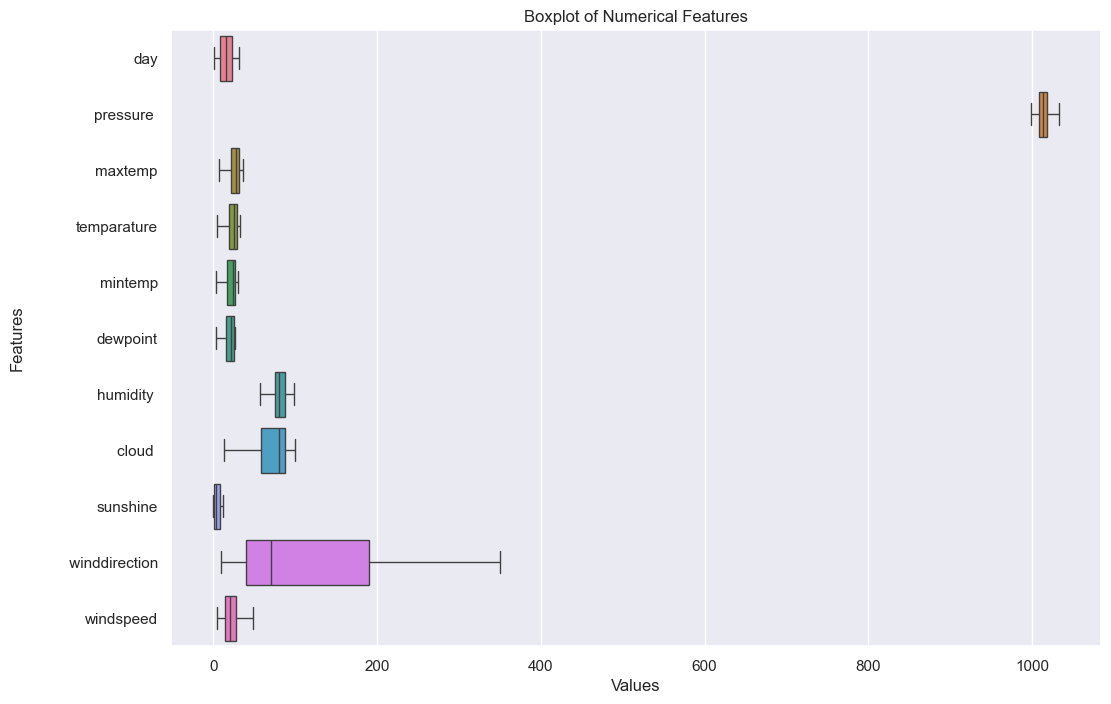

In [124]:
plt.figure(figsize=(12, 8))

sns.boxplot(rainfall.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

### `Data Visualization`

`Pie chart` distribution on target variable

In [125]:
target_count = rainfall['rainfall'].value_counts()

print(target_count)

rainfall
yes    249
no     117
Name: count, dtype: int64


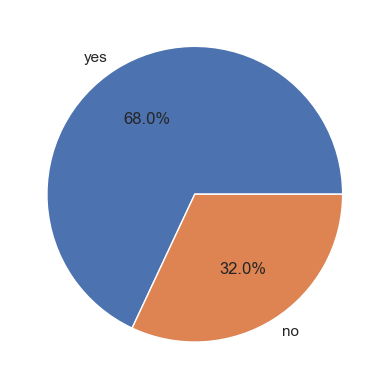

In [126]:
plt.pie(rainfall['rainfall'].value_counts().values,
        labels=rainfall['rainfall'].value_counts().index,
        autopct='%1.1f%%')

plt.show()

`Subplot` distribution of Numerical Features

In [127]:
features = list(rainfall.select_dtypes(include=[np.number]).columns)
features.remove('day')
print(features)

['pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity ', 'cloud ', 'sunshine', '         winddirection', 'windspeed']


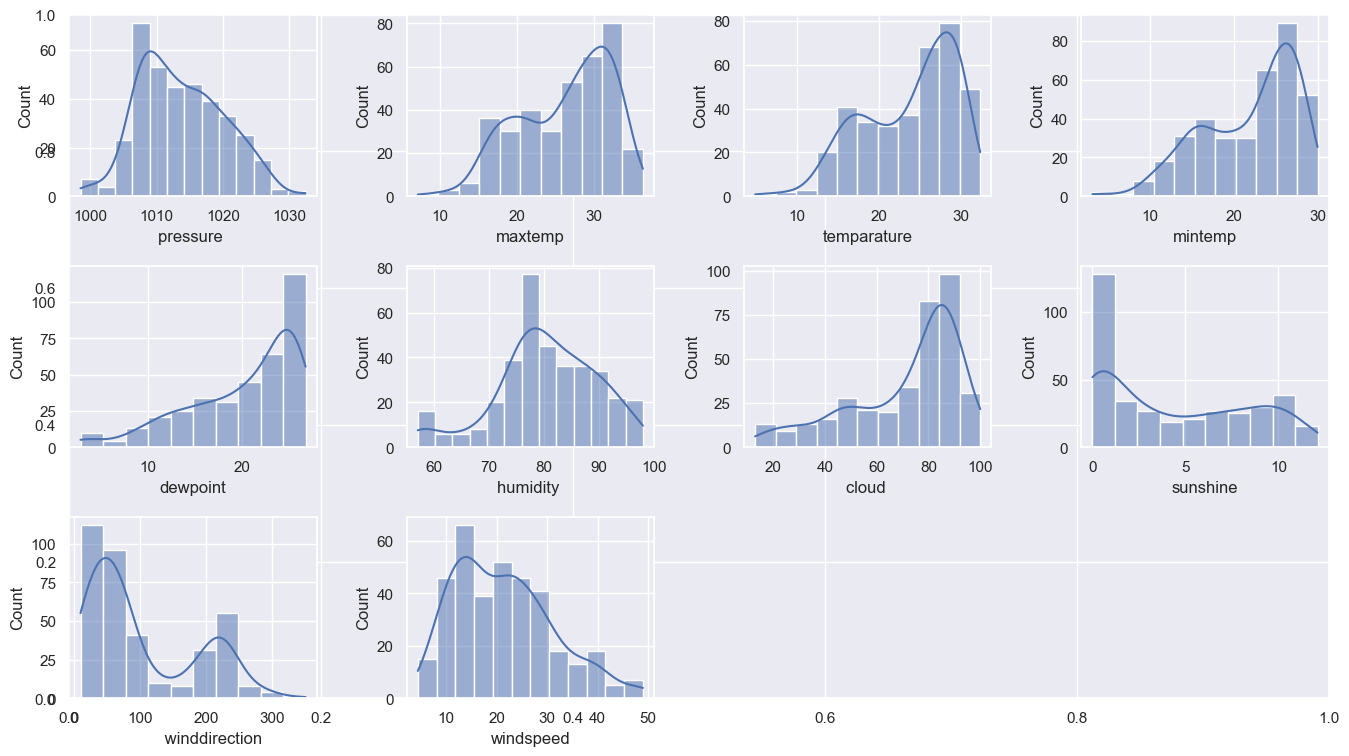

In [128]:
plt.subplots(figsize=(14, 8))

for i, col in enumerate(features):
    plt.subplot(3, 4, i + 1)
    sns.histplot(rainfall[col], kde=True)
plt.tight_layout()
plt.show()

### `Correlation` Heatmap

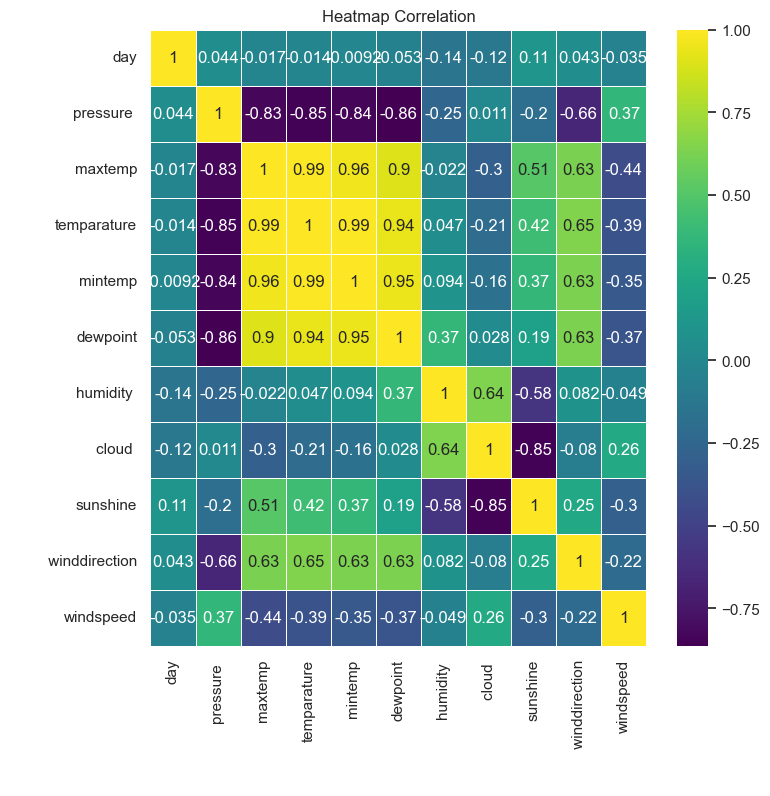

In [129]:
correlation = rainfall.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 8))
sns.heatmap(correlation, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Heatmap Correlation')
plt.show()

## `Feature Encoding`

`Encoding` Target variable for Model Training and Evaluation using `Mapping` funtion since its a binary classification

In [130]:
rainfall['rainfall'] = rainfall['rainfall'].map({'yes' : 1, 'no' : 0})

In [131]:
rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1.0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,1,9.3,80.0,26.3
1,2.0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,1,0.6,50.0,15.3
2,3.0,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,1,0.0,40.0,14.2
3,4.0,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1,1.0,50.0,16.9
4,5.0,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,1,0.0,40.0,13.7


## `Feature Selection` and `Data Splitting`

In [132]:
X = rainfall.drop(['rainfall', 'day'], axis=1)
y = rainfall['rainfall']

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
X_train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
341,1023.1,19.3,17.3,15.4,12.1,72.0,86.0,0.9,10.0,21.8
202,1010.9,33.3,30.0,27.5,25.3,76.0,49.0,8.8,220.0,12.3
75,1015.0,16.3,15.3,14.1,13.6,90.0,100.0,0.0,60.0,33.2
84,1023.9,15.7,13.7,11.6,9.2,75.0,88.0,0.2,20.0,19.4
354,1022.5,18.6,17.6,17.0,12.9,75.0,88.0,0.0,40.0,19.0


In [135]:
X_test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
193,1003.8,29.0,28.1,27.0,25.1,84.0,88.0,0.0,230.0,16.3
33,1023.6,14.3,12.5,10.3,8.6,77.0,88.0,0.3,40.0,21.3
15,1013.5,17.1,16.4,15.5,15.6,95.0,93.0,0.0,60.0,40.0
310,1015.6,26.3,25.5,24.7,22.4,83.0,81.0,0.5,80.0,30.2
57,1024.7,17.5,15.5,13.8,11.7,79.0,79.0,5.0,20.0,9.1


In [136]:
y_train.head()

341    0
202    1
75     1
84     1
354    1
Name: rainfall, dtype: int64

In [137]:
y_test.head()

193    1
33     1
15     1
310    1
57     1
Name: rainfall, dtype: int64

### `Model Training, Prediction and Evaluation`

### `Logistic Regression`

In [138]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(y_pred)

[1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1
 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0]


`Model Accuracy`

In [139]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.74


`Classification Report`

In [140]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.52      0.56        23
           1       0.80      0.84      0.82        51

    accuracy                           0.74        74
   macro avg       0.70      0.68      0.69        74
weighted avg       0.74      0.74      0.74        74



In [141]:
ras = roc_auc_score(y_test, y_pred)
print('Roc Auc Score: ', ras)

Roc Auc Score:  0.6824381926683717


`RocCurveDisplay`

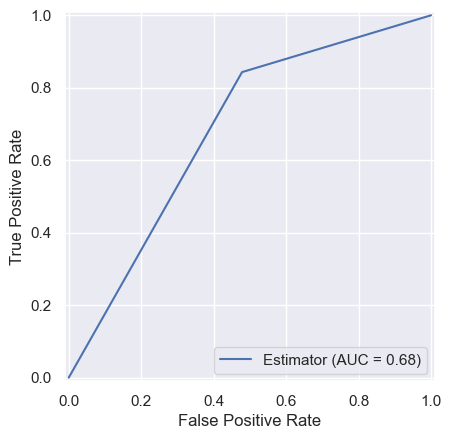

In [142]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
lr_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=lr_roc_auc, name='Estimator')
display.plot()
plt.show()

`Cross Validation`

In [143]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.78378378 0.79452055 0.82191781 0.76712329 0.73972603]
Mean Cross-Validation Accuracy: 0.781 (+/- 0.055)


### `Confusion Matrix`

Confusion Matrix:
 [[12 11]
 [ 8 43]]


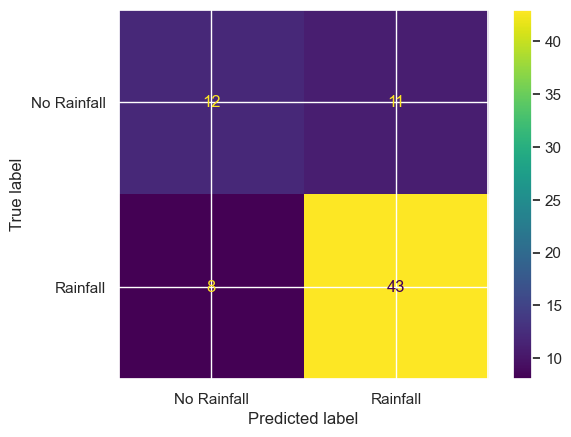

In [144]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `RandomForestClassifier`

In [145]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(y_pred)

[1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1]


`Model Accuracy`

In [146]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.74


`Classification Report`

In [147]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.48      0.54        23
           1       0.79      0.86      0.82        51

    accuracy                           0.74        74
   macro avg       0.70      0.67      0.68        74
weighted avg       0.73      0.74      0.73        74



In [148]:
ras = roc_auc_score(y_test, y_pred)
print('Roc Auc Score: ', ras)

Roc Auc Score:  0.6705029838022166


`RocCurveDisplay`

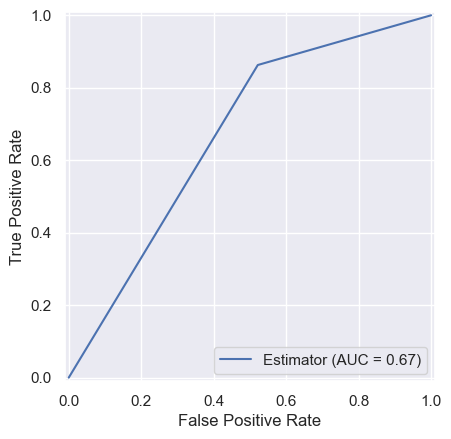

In [149]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
dtc_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=dtc_roc_auc, name='Estimator')
display.plot()
plt.show()


`Cross Validation`

In [150]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rfc, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.86486486 0.83561644 0.78082192 0.79452055 0.71232877]
Mean Cross-Validation Accuracy: 0.798 (+/- 0.104)


### `Confusion Matrix`

Confusion Matrix:
 [[11 12]
 [ 7 44]]


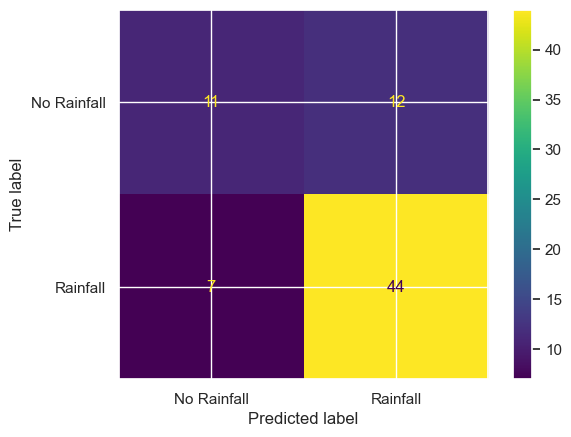

In [151]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `DecisionTreeClassifier`

In [152]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

In [153]:
print(y_pred)

[1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1
 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0 1]


`Model Accuracy`

In [154]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.68


`Classification Report`

In [155]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.35      0.40        23
           1       0.74      0.82      0.78        51

    accuracy                           0.68        74
   macro avg       0.60      0.59      0.59        74
weighted avg       0.65      0.68      0.66        74



In [156]:
ras = roc_auc_score(y_test, y_pred)

print('Roc Auc Score: ', ras)

Roc Auc Score:  0.5856777493606138


`RocCurveDisplay`

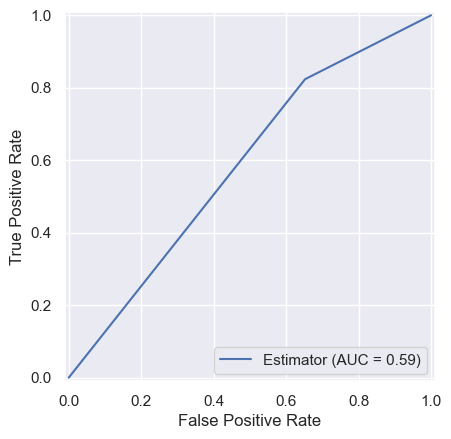

In [157]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
dtc_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=dtc_roc_auc, name='Estimator')
display.plot()
plt.show()


`Cross Validation`

In [158]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dtc, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.71621622 0.78082192 0.80821918 0.67123288 0.69863014]
Mean Cross-Validation Accuracy: 0.735 (+/- 0.103)


### `Confusion Matrix`

Confusion Matrix:
 [[ 8 15]
 [ 9 42]]


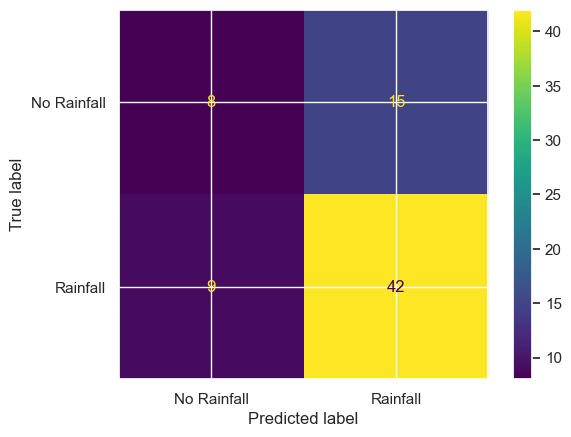

In [159]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `XGBClassifier`

In [160]:
xgb = XGBClassifier(class_weight='balanced', random_state=42)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print(y_pred)

[1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0]


`Model Accuracy`

In [161]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Acurracy: {accuracy:.2f}')

Model Acurracy: 0.68


`Classification Report`

In [162]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.43      0.45        23
           1       0.75      0.78      0.77        51

    accuracy                           0.68        74
   macro avg       0.62      0.61      0.61        74
weighted avg       0.67      0.68      0.67        74



In [163]:
ras = roc_auc_score(y_test, y_pred)

print('Roc Auc Score: ', ras)

Roc Auc Score:  0.6095481670929241


`RocCurveDisplay`

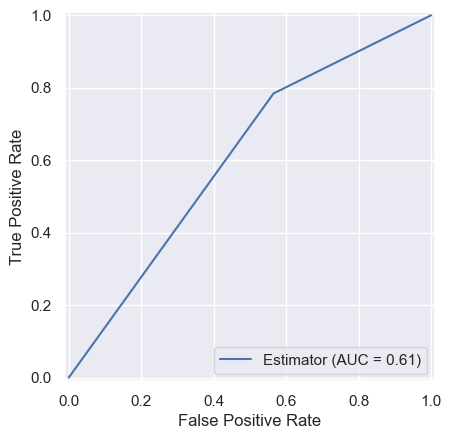

In [164]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
xgb_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=xgb_roc_auc, name='Estimator')
display.plot()
plt.show()


`Cross Validation`

In [165]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.82432432 0.80821918 0.78082192 0.78082192 0.69863014]
Mean Cross-Validation Accuracy: 0.779 (+/- 0.087)


### `Confusion Matrix`

Confusion Matrix:
 [[10 13]
 [11 40]]


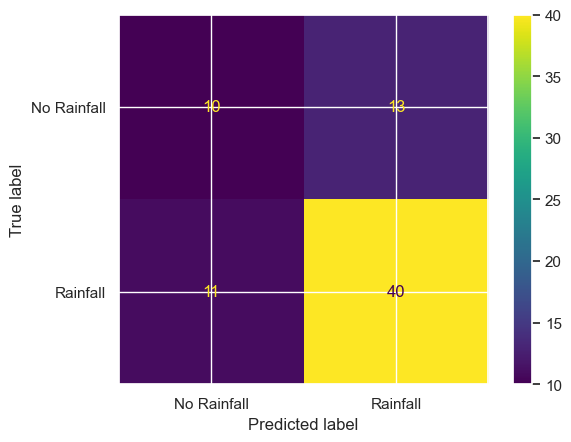

In [166]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

## `Tuning Hyperparameter`

Tuning hyperparameter on `Scaled Logistic Regression`

### Using `RandomizedSearchCV`

In [167]:
param_dist = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga'],
    'lr__max_iter': [100, 200, 300]
}

search = RandomizedSearchCV(
    estimator=pipe, 
    param_distributions=param_dist, 
    n_iter=15,
    cv=3, 
    scoring='accuracy', 
    n_jobs=1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)


print('Best Param: ', search.best_params_)
print('Best CV Score: ', search.best_score_, 4)


# Evaluate on test set

y_pred = search.predict(X_test)
print('\nTest Set Report:')
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Param:  {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__max_iter': 100, 'lr__C': 0.01}
Best CV Score:  0.8117329405989199 4

Test Set Report:
              precision    recall  f1-score   support

           0       0.63      0.52      0.57        23
           1       0.80      0.86      0.83        51

    accuracy                           0.76        74
   macro avg       0.72      0.69      0.70        74
weighted avg       0.75      0.76      0.75        74

